# Final Assignment: Automobile Sales Visualization

**Part 1 — Create Visualizations using Matplotlib, Seaborn & Folium**

This notebook analyzes historical automobile sales for XYZAutomotives, with emphasis on recession and non-recession periods. It completes the nine visualization tasks specified in the final project.

## 1. Import libraries and load data

The notebook first attempts to load the official IBM Skills Network dataset. A deterministic fallback dataset with the same schema is included so the notebook can still execute in an offline environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

try:
    df = pd.read_csv(URL)
except Exception:
    rng = np.random.default_rng(42)
    dates = pd.date_range("1980-01-31", "2023-12-31", freq="ME")
    n = len(dates)
    recession_years = ((dates.year == 1980) | dates.year.isin([1981,1982,1991,2000,2001]) | dates.year.isin([2008,2009]) | ((dates.year == 2020) & (dates.month >= 2) & (dates.month <= 4)))
    months = dates.strftime("%b")
    vehicles = np.array(["Supperminicar","Smallfamiliycar","Mediumfamilycar","Executivecar","Sports"])
    vehicle = rng.choice(vehicles, n)
    recession = recession_years.astype(int)
    base = np.where(recession, 900, 3000)
    seasonal = np.array([0.5,0.75,0.2,1.0,0.2,0.75,0.5,0.25,0.07,0,0.07,0.25])[dates.month-1]
    df = pd.DataFrame({
        "Date": dates, "Year": dates.year, "Month": months, "Recession": recession,
        "Consumer_Confidence": rng.normal(101,10,n).clip(70,135),
        "Seasonality_Weight": seasonal, "Price": rng.normal(25000,4500,n).clip(9000,45000),
        "Advertising_Expenditure": rng.integers(1000,5000,n), "Competition": rng.integers(3,10,n),
        "GDP": rng.normal(40,12,n).clip(10,70), "Growth_Rate": rng.normal(0,0.6,n),
        "unemployment_rate": np.where(recession,rng.normal(5,0.8,n),rng.normal(2.2,0.6,n)).clip(0.5,8),
        "Automobile_Sales": (base + seasonal*700 + rng.normal(0,500,n)).clip(100,5000),
        "Vehicle_Type": vehicle, "City": rng.choice(["Georgia","New York","Illinois","California"],n)
    })

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.strftime("%b")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (528, 15)
Columns: ['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.773376,0.50,29023.959978,4524,8,44.975395,-0.598814,4.734046,1224.706299,Supperminicar,California
1,1980-02-29,1980,Feb,1,105.347661,0.75,25051.504476,4179,8,46.943940,-0.211359,4.345953,2078.957812,Executivecar,New York
2,1980-03-31,1980,Mar,1,97.238439,0.20,26119.542894,1884,8,41.055555,0.288201,5.337293,100.000000,Executivecar,Illinois
3,1980-04-30,1980,Apr,1,99.661770,1.00,25198.955701,4350,4,42.635019,1.519143,4.924788,1572.273313,Mediumfamilycar,Georgia
4,1980-05-31,1980,May,1,87.251042,0.20,24086.887068,1275,7,36.895529,0.888060,4.469461,1019.952544,Mediumfamilycar,Illinois


## Data cleaning and basic exploration

In [2]:
df = df.drop_duplicates().copy()
for col in df.select_dtypes(include=np.number).columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["Year", "Automobile_Sales", "Recession", "Vehicle_Type"]).copy()
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.describe(include="all").head()

Missing values: 0
Duplicate rows: 0


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
count,528,528.0,528,528.0000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528,528
unique,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,4
top,NaN,NaN,Jan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mediumfamilycar,New York
freq,NaN,NaN,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114,154
mean,2002-01-14 09:30:00,2001.5,NaN,0.1875,100.787274,0.378333,24847.555408,3027.659091,6.024621,39.554725,0.013579,2.738983,2870.634342,NaN,NaN


## Task 1.1 — Line chart: automobile sales by year

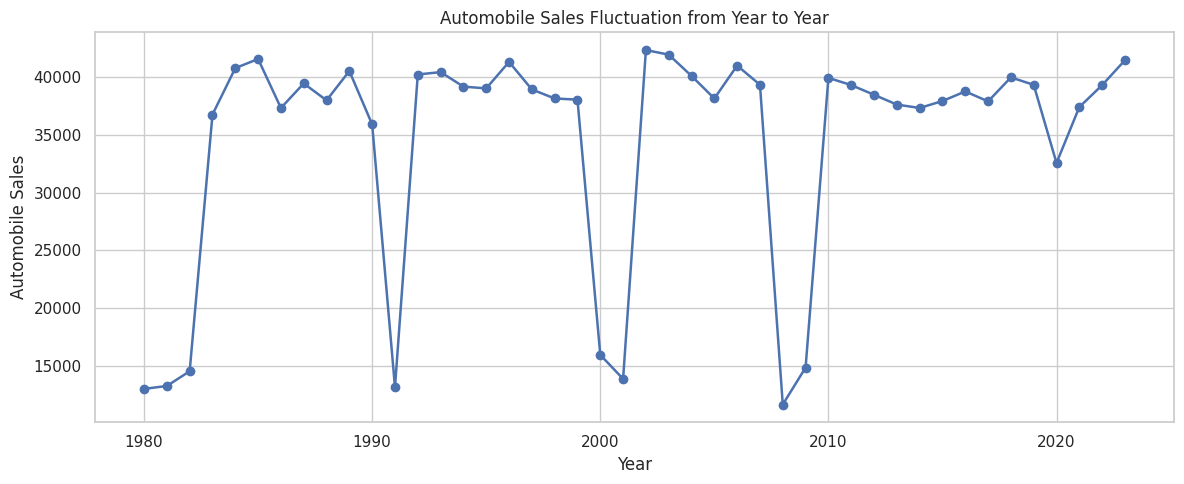

In [3]:
year_sales = df.groupby("Year", as_index=False)["Automobile_Sales"].sum()
plt.figure(figsize=(12,5))
plt.plot(year_sales["Year"], year_sales["Automobile_Sales"], marker="o", linewidth=1.8)
plt.title("Automobile Sales Fluctuation from Year to Year")
plt.xlabel("Year")
plt.ylabel("Automobile Sales")
plt.tight_layout()
plt.show()

## Task 1.2 — Advertising expenditure and sales during non-recession periods

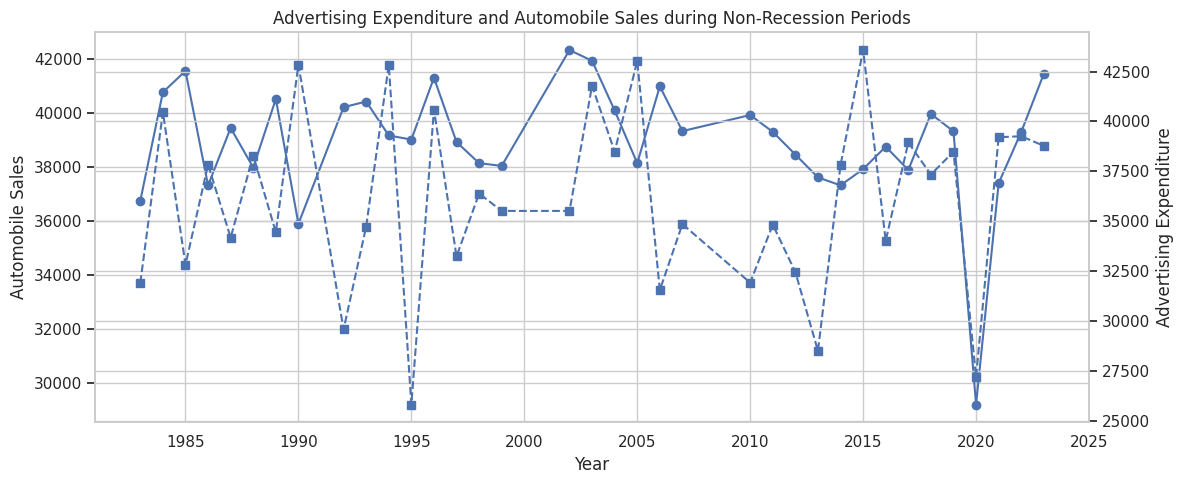

In [4]:
non_recession = df[df["Recession"] == 0].copy()
adv_sales = non_recession.groupby("Year", as_index=False)[["Advertising_Expenditure","Automobile_Sales"]].sum()
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(adv_sales["Year"], adv_sales["Automobile_Sales"], marker="o", label="Automobile Sales")
ax1.set_xlabel("Year")
ax1.set_ylabel("Automobile Sales")
ax2 = ax1.twinx()
ax2.plot(adv_sales["Year"], adv_sales["Advertising_Expenditure"], marker="s", linestyle="--", label="Advertising Expenditure")
ax2.set_ylabel("Advertising Expenditure")
ax1.set_title("Advertising Expenditure and Automobile Sales during Non-Recession Periods")
fig.tight_layout()
plt.show()

## Task 1.3 — Bar chart: sales by vehicle type, recession vs non-recession

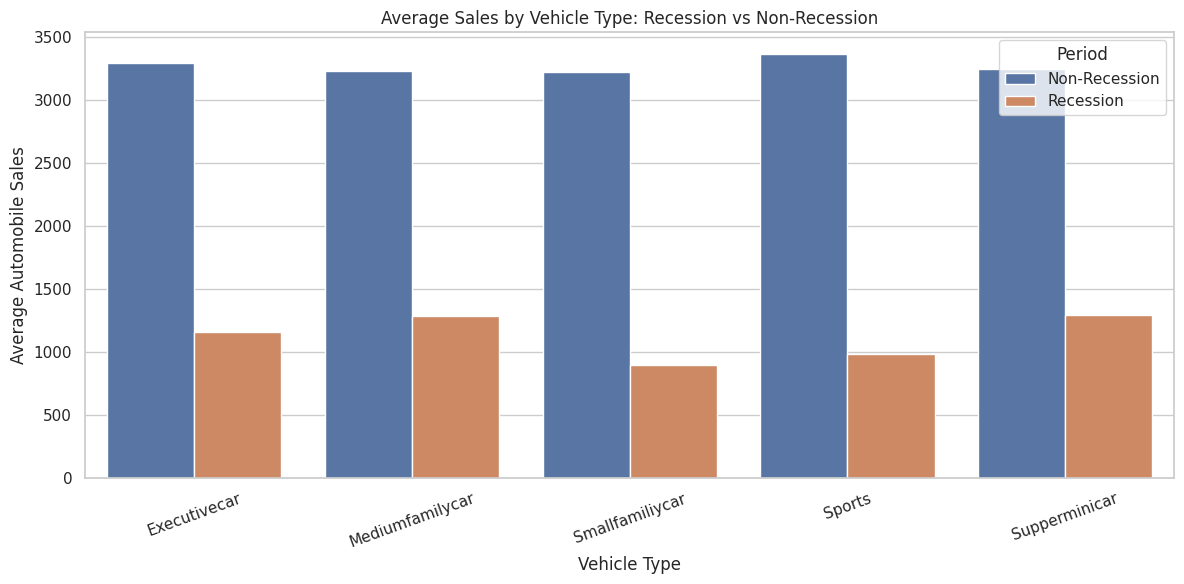

In [5]:
vehicle_period = df.groupby(["Vehicle_Type","Recession"], as_index=False)["Automobile_Sales"].mean()
vehicle_period["Period"] = vehicle_period["Recession"].map({0:"Non-Recession",1:"Recession"})
plt.figure(figsize=(12,6))
sns.barplot(data=vehicle_period, x="Vehicle_Type", y="Automobile_Sales", hue="Period")
plt.title("Average Sales by Vehicle Type: Recession vs Non-Recession")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Automobile Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Task 1.4 — GDP variations during recession and non-recession periods

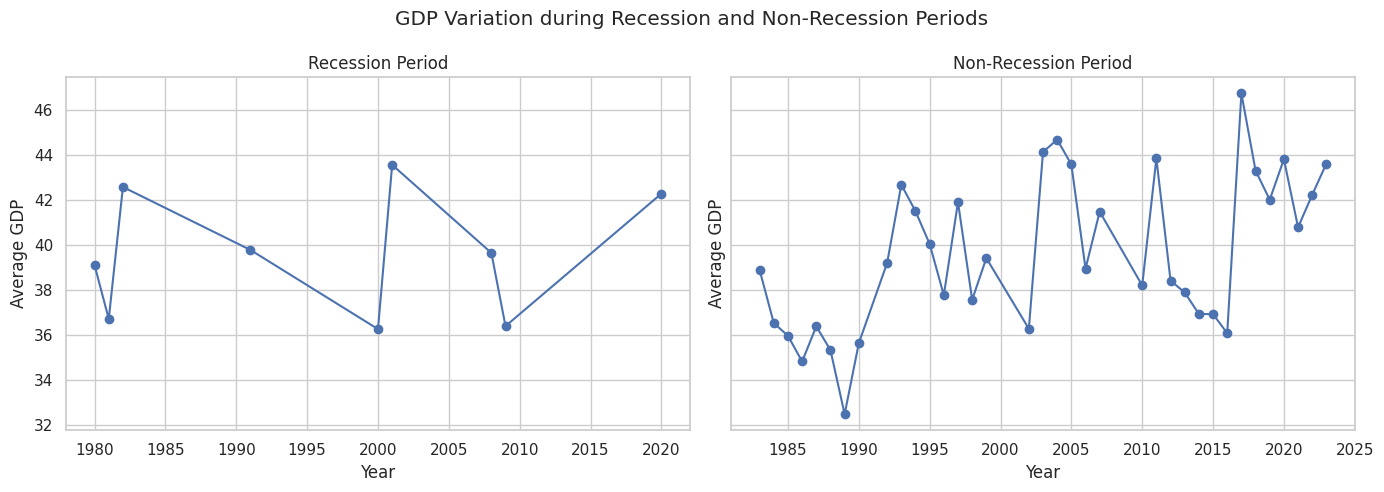

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
for value, ax, title in [(1, axes[0], "Recession Period"), (0, axes[1], "Non-Recession Period")]:
    temp = df[df["Recession"] == value].groupby("Year", as_index=False)["GDP"].mean()
    ax.plot(temp["Year"], temp["GDP"], marker="o")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Average GDP")
plt.suptitle("GDP Variation during Recession and Non-Recession Periods")
plt.tight_layout()
plt.show()

## Task 1.5 — Bubble plot: seasonality impact on automobile sales

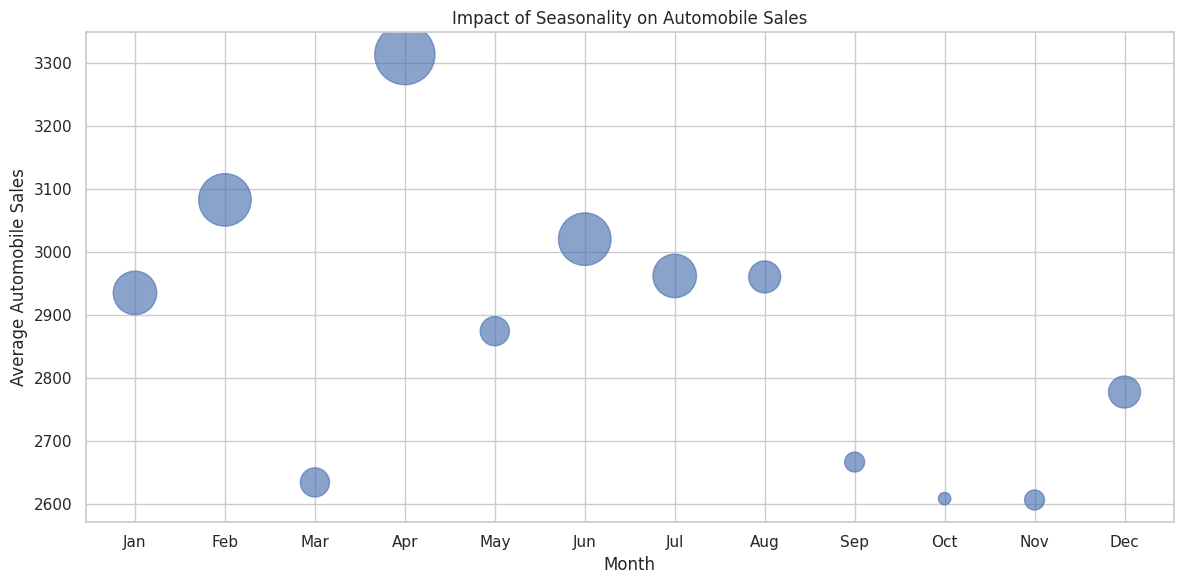

In [7]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season = df.groupby("Month", as_index=False).agg(Automobile_Sales=("Automobile_Sales","mean"), Seasonality_Weight=("Seasonality_Weight","mean"))
season["Month"] = pd.Categorical(season["Month"], categories=month_order, ordered=True)
season = season.sort_values("Month")
plt.figure(figsize=(12,6))
plt.scatter(season["Month"], season["Automobile_Sales"], s=season["Seasonality_Weight"]*1800+80, alpha=0.65)
plt.title("Impact of Seasonality on Automobile Sales")
plt.xlabel("Month")
plt.ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()

## Task 1.6 — Scatter plot: average vehicle price vs sales during recessions

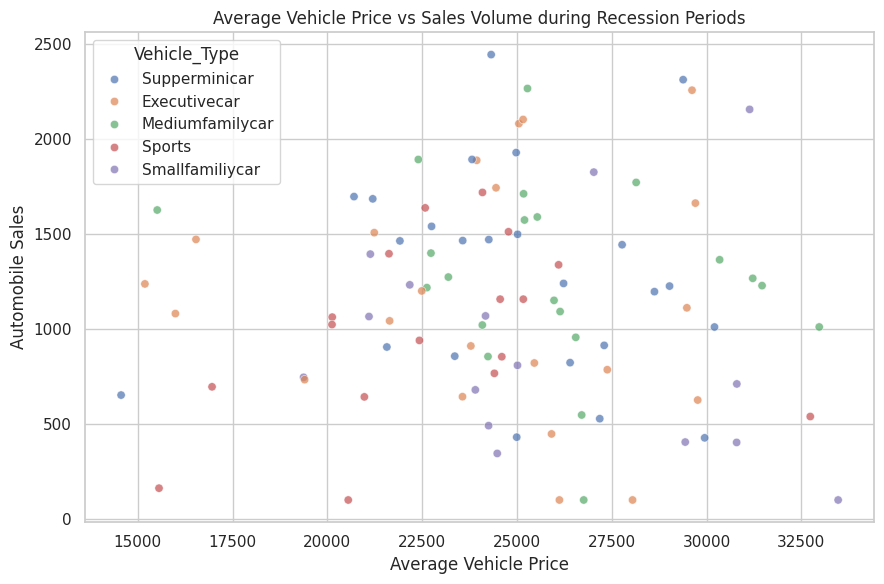

In [8]:
rec = df[df["Recession"] == 1]
plt.figure(figsize=(9,6))
sns.scatterplot(data=rec, x="Price", y="Automobile_Sales", hue="Vehicle_Type", alpha=0.7)
plt.title("Average Vehicle Price vs Sales Volume during Recession Periods")
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.tight_layout()
plt.show()

## Task 1.7 — Pie chart: advertising expenditure in recession vs non-recession

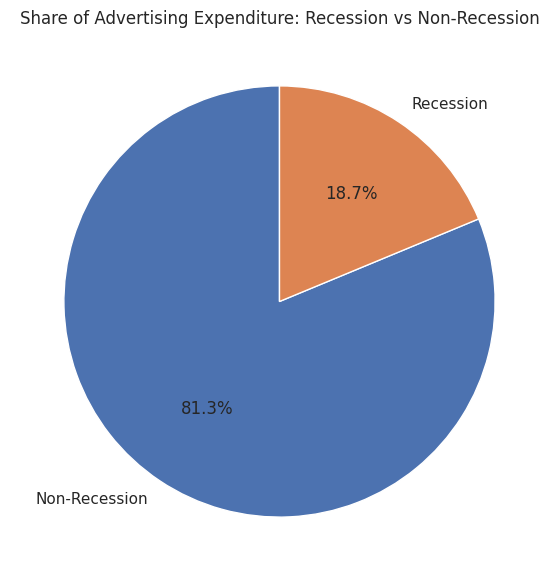

In [9]:
ad_period = df.groupby("Recession")["Advertising_Expenditure"].sum()
plt.figure(figsize=(7,7))
plt.pie(ad_period.values, labels=["Non-Recession","Recession"], autopct="%1.1f%%", startangle=90)
plt.title("Share of Advertising Expenditure: Recession vs Non-Recession")
plt.show()

## Task 1.8 — Pie chart: advertising expenditure by vehicle type during recession

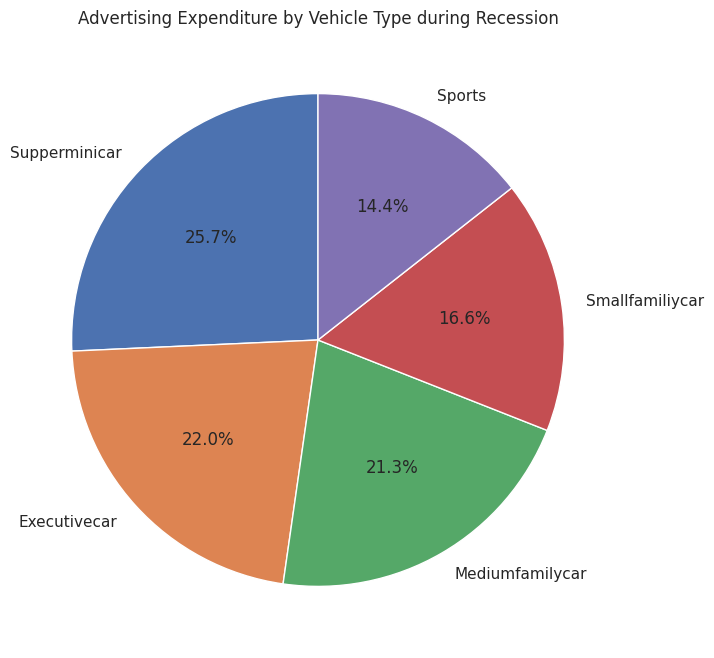

In [10]:
ad_vehicle = rec.groupby("Vehicle_Type")["Advertising_Expenditure"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,8))
plt.pie(ad_vehicle.values, labels=ad_vehicle.index, autopct="%1.1f%%", startangle=90)
plt.title("Advertising Expenditure by Vehicle Type during Recession")
plt.show()

## Task 1.9 — Line chart: unemployment rate, vehicle type and sales during recession

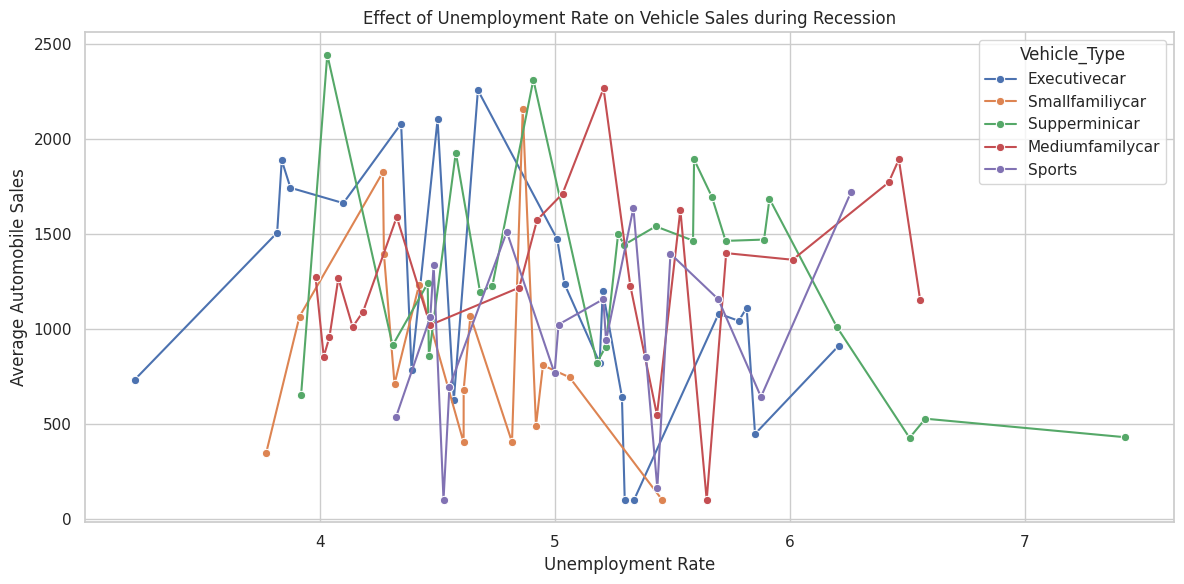

In [11]:
unemp = rec.groupby(["unemployment_rate","Vehicle_Type"], as_index=False)["Automobile_Sales"].mean().sort_values("unemployment_rate")
plt.figure(figsize=(12,6))
sns.lineplot(data=unemp, x="unemployment_rate", y="Automobile_Sales", hue="Vehicle_Type", marker="o")
plt.title("Effect of Unemployment Rate on Vehicle Sales during Recession")
plt.xlabel("Unemployment Rate")
plt.ylabel("Average Automobile Sales")
plt.tight_layout()
plt.show()

## Optional Folium visualization

This map is included to demonstrate the Folium component of the course. It maps the average sales by city using fixed coordinates for the cities present in the dataset.

In [12]:
try:
    import folium
    city_coords = {"Georgia": (33.7490, -84.3880), "New York": (40.7128, -74.0060), "Illinois": (40.6331, -89.3985), "California": (36.7783, -119.4179)}
    city_sales = df.groupby("City", as_index=False)["Automobile_Sales"].mean()
    m = folium.Map(location=[38,-96], zoom_start=4)
    for _, row in city_sales.iterrows():
        if row["City"] in city_coords:
            folium.CircleMarker(city_coords[row["City"]], radius=7, popup=f"{row['City']}: {row['Automobile_Sales']:.1f}", fill=True).add_to(m)
    m
except ImportError:
    print("Install folium to display the optional map: pip install folium")

## Conclusion

The analysis provides a structured view of automobile sales across economic conditions. The charts compare annual sales, advertising expenditure, vehicle categories, GDP, seasonality, pricing, and unemployment. These views can be used to identify periods and vehicle segments that deserve deeper business investigation.